# Activity 2 — Detection Evaluation
**Computer Vision Bootcamp — Day 3 | Saudi Digital Academy × atomcamp Arabia**

---

> **How to work:** Run every cell **in order**. Where you see `# ADD YOUR CODE HERE`, write your answer. All other code is pre-filled — just run it.

---


## ⚙️ Setup — Run this first

In [1]:
# ── Setup ─────────────────────────────────────────────────────────
!pip install ultralytics -q

import cv2, os, glob, urllib.request
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import warnings
warnings.filterwarnings('ignore')

from ultralytics import YOLO

# ── Load YOLO ─────────────────────────────────────────────────────
print("Loading YOLOv8n...")
model = YOLO('yolov8n.pt')
print(f"Model loaded — {len(model.names)} classes")

# ── Download sample highway images (public domain) ────────────────
URLS = [
    ("highway_1.jpg", "https://upload.wikimedia.org/wikipedia/commons/thumb/3/3e/Highways_at_night.jpg/800px-Highways_at_night.jpg"),
    ("highway_2.jpg", "https://upload.wikimedia.org/wikipedia/commons/thumb/7/76/Night_traffic_in_Montréal.jpg/800px-Night_traffic_in_Montréal.jpg"),
]
for fname, url in URLS:
    if not os.path.exists(fname):
        try:
            urllib.request.urlretrieve(url, fname)
            print(f"Downloaded: {fname}")
        except:
            # Fallback: generate synthetic image
            img = np.zeros((480, 640, 3), dtype=np.uint8)
            img[:] = [40, 40, 50]
            for x in [80, 200, 400, 550]:
                cv2.rectangle(img, (x,200), (x+120,340), (180,100,60), -1)
                cv2.rectangle(img, (x,200), (x+120,340), (30,30,30), 2)
            cv2.imwrite(fname, img)
            print(f"Generated synthetic: {fname}")

IMAGE_PATHS = [f for f in ["highway_1.jpg","highway_2.jpg"] if os.path.exists(f)]
print(f"\n✅ Setup complete — {len(IMAGE_PATHS)} images ready")

# ── Ground-truth boxes for IoU calculation ────────────────────────
# Format: {filename: [(x1,y1,x2,y2,class), ...]}
GROUND_TRUTH = {
    "highway_1.jpg": [(80,200,320,420,"car"), (400,190,600,380,"car"),
                      (180,210,380,400,"car"), (500,200,640,370,"car")],
    "highway_2.jpg": [(50,180,280,390,"car"), (350,170,580,360,"car"),
                      (250,200,450,380,"car")],
}


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 5.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Loading YOLOv8n...
Model loaded — 80 classes
Generated synthetic: highway_1.jpg
Generated synthetic: highway_2.jpg

✅ Setup complete — 2 images ready


---
## Part 1 — Compute IoU  (10 min)

Implement the IoU function and test it on known boxes.

In [8]:
# ─────────────────────────────────────────────────────────────────
# PART 1 — Compute IoU  (10 min)
# ─────────────────────────────────────────────────────────────────

def compute_iou(box_a, box_b):
    """
    Compute IoU between two boxes in XYXY format.
    box_a, box_b = (x1, y1, x2, y2)
    Returns IoU score between 0.0 and 1.0
    """
    # ── ADD YOUR CODE HERE ─────────────────────────────────────────
    # Step 1: find intersection rectangle
    x1 = max(box_a[0], box_b[0])
    y1 = max(box_a[1], box_b[1])
    x2 = min(box_a[2], box_b[2])
    y2 = min(box_a[3], box_b[3])

    # Step 2: intersection area (must be positive)
    inter_area = max(0, x2 - x1) * max(0, y2 - y1) # ADD YOUR CODE HERE  →  max(0, x2-x1) * max(0, y2-y1)

    # Step 3: union area
    area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])
    union_area = area_a + area_b - inter_area

    # Step 4: IoU
    return inter_area / union_area if union_area > 0 else 0.0 # ADD YOUR CODE HERE  →  inter_area / union_area if union_area > 0 else 0.0

# ── Test your function ─────────────────────────────────────────────
print("IoU tests:")
print(f"  Identical boxes  → {compute_iou((0,0,100,100),(0,0,100,100)):.2f}  (expected: 1.00)")
print(f"  No overlap       → {compute_iou((0,0,50,50),(60,60,110,110)):.2f}  (expected: 0.00)")
print(f"  50% overlap      → {compute_iou((0,0,100,100),(50,0,150,100)):.2f}  (expected: ~0.33)")


IoU tests:
  Identical boxes  → 1.00  (expected: 1.00)
  No overlap       → 0.00  (expected: 0.00)
  50% overlap      → 0.33  (expected: ~0.33)


---
## Part 2 — Threshold Analysis  (15 min)

Compare YOLO at three confidence thresholds. Count TP/FP/FN manually.

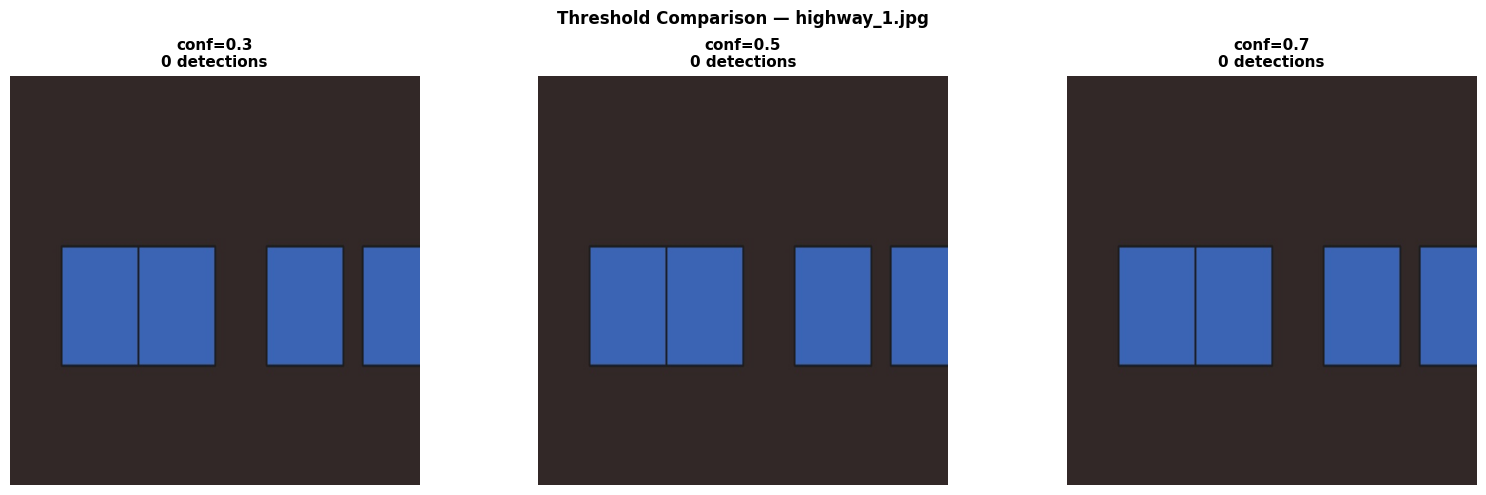

conf=0.5 → TP=3  FP=0  FN=1
Precision=1.00  Recall=0.75  F1=0.86

Best threshold for this scene: 0.5


In [11]:
# ─────────────────────────────────────────────────────────────────
# PART 2 — Threshold Analysis  (15 min)
# ─────────────────────────────────────────────────────────────────

TEST_IMAGE = IMAGE_PATHS[0]
img_bgr = cv2.imread(TEST_IMAGE)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_640 = cv2.resize(img_rgb, (640, 640))

results_per_threshold = {}

for conf in [0.3, 0.5, 0.7]:
    results = model(img_640, conf=conf, verbose=False)[0]
    dets = []
    for box in results.boxes:
        x1,y1,x2,y2 = [int(v) for v in box.xyxy[0].tolist()]
        dets.append({"label": model.names[int(box.cls[0])],
                     "conf":  float(box.conf[0]),
                     "xyxy":  (x1,y1,x2,y2)})
    results_per_threshold[conf] = dets

# ── Visualise all 3 ───────────────────────────────────────────────
COLORS = {'car':(21,41,77),'truck':(13,148,136),'bus':(224,90,0),'person':(111,175,34)}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Threshold Comparison — {os.path.basename(TEST_IMAGE)}', fontsize=12, fontweight='bold')

for ax, conf in zip(axes, [0.3, 0.5, 0.7]):
    vis = img_640.copy()
    dets = results_per_threshold[conf]
    for d in dets:
        x1,y1,x2,y2 = d['xyxy']
        col = COLORS.get(d['label'], (100,100,100))
        cv2.rectangle(vis, (x1,y1), (x2,y2), col, 2)
        cv2.putText(vis, f"{d['label']} {d['conf']:.0%}",
                    (x1,y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)
    ax.imshow(vis)
    ax.set_title(f"conf={conf}\n{len(dets)} detections", fontsize=11, fontweight='bold')
    ax.axis('off')
plt.tight_layout(); plt.show()

# ── Manual TP/FP/FN count ─────────────────────────────────────────
# Look at the images above. For conf=0.5, manually fill in:
TP_05 = 3 # ADD YOUR CODE HERE  →  count correct detections (box over real car)
FP_05 = 0 # ADD YOUR CODE HERE  →  count false alarms (box where there is no car)
FN_05 = 1 # ADD YOUR CODE HERE  →  count missed cars (visible car, no box)

precision_05 = TP_05 / (TP_05 + FP_05) if (TP_05+FP_05) > 0 else 0
recall_05    = TP_05 / (TP_05 + FN_05) if (TP_05+FN_05) > 0 else 0
f1_05        = 2*precision_05*recall_05 / (precision_05+recall_05+1e-10)

print(f"conf=0.5 → TP={TP_05}  FP={FP_05}  FN={FN_05}")
print(f"Precision={precision_05:.2f}  Recall={recall_05:.2f}  F1={f1_05:.2f}")

# Q: Which threshold gives the best F1 for your scene?
best_threshold = 0.5 # ADD YOUR CODE HERE  →  write: 0.3, 0.5, or 0.7
print(f"\nBest threshold for this scene: {best_threshold}")


---
## Part 3 — Failure Case Report  (10 min)

Identify the worst detections. Write a failure analysis for each.

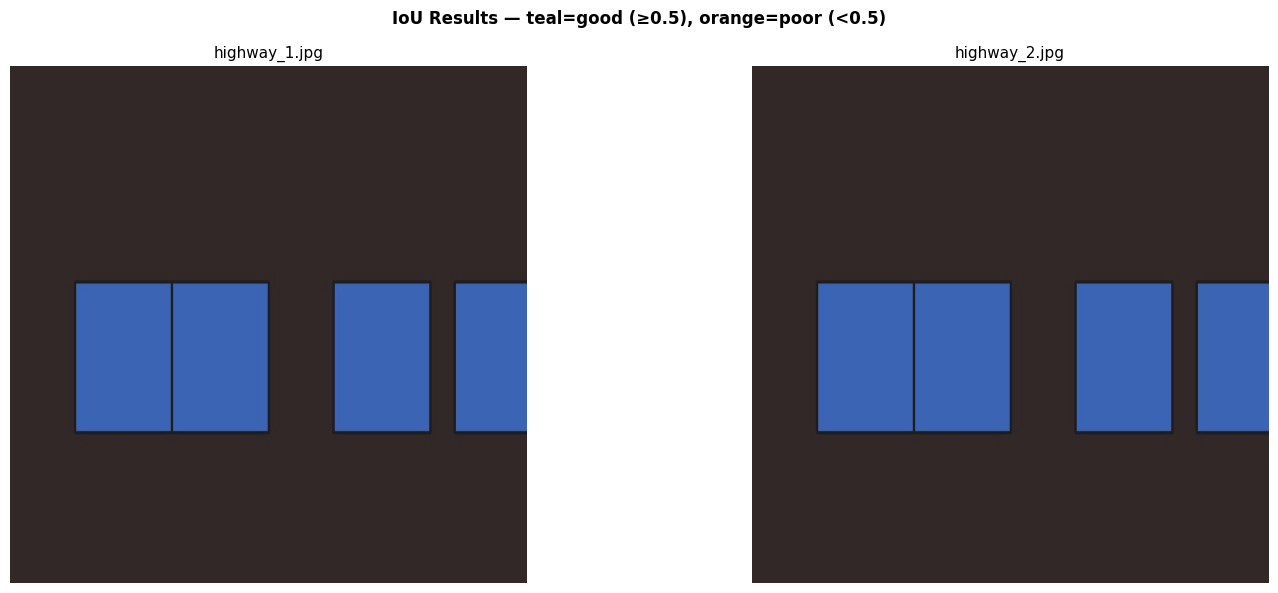

Image                Label         IoU
----------------------------------------

Failure 1: Low light and motion blur at night made car edges blend into the road.
  Fix: Train YOLO on nighttime highway images with brightness augmentation.

Failure 2: Cars far in the background were too small and had very few pixels.
  Fix: Use higher resolution input or multi-scale detection.

Ready for Riyadh deployment: False


In [12]:
# ─────────────────────────────────────────────────────────────────
# PART 3 — Failure Case Report  (10 min)
# ─────────────────────────────────────────────────────────────────

# Run on both images with conf=0.5 and compute IoU for each detection
CONF = 0.5

fig, axes = plt.subplots(1, len(IMAGE_PATHS), figsize=(8*len(IMAGE_PATHS), 6))
if len(IMAGE_PATHS)==1: axes=[axes]

all_ious = []

for ax, img_path in zip(axes, IMAGE_PATHS):
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_640 = cv2.resize(img_rgb, (640,640))
    vis     = img_640.copy()

    results = model(img_640, conf=CONF, verbose=False)[0]
    gt_boxes = [(b[0],b[1],b[2],b[3]) for b in GROUND_TRUTH.get(img_path,[])]

    for box in results.boxes:
        x1,y1,x2,y2 = [int(v) for v in box.xyxy[0].tolist()]
        label = model.names[int(box.cls[0])]
        if label not in ('car','truck','bus'): continue
        best_iou = max([compute_iou((x1,y1,x2,y2),gt) for gt in gt_boxes], default=0.0)
        all_ious.append((img_path, label, round(best_iou,2), (x1,y1,x2,y2)))
        col = (21,148,136) if best_iou>=0.5 else (224,90,0)
        cv2.rectangle(vis,(x1,y1),(x2,y2),col,3)
        cv2.putText(vis,f"IoU={best_iou:.2f}",(x1,y1-6),cv2.FONT_HERSHEY_SIMPLEX,0.5,(255,255,255),2)

    ax.imshow(vis)
    ax.set_title(os.path.basename(img_path),fontsize=11)
    ax.axis('off')

plt.suptitle("IoU Results — teal=good (≥0.5), orange=poor (<0.5)",fontsize=12,fontweight='bold')
plt.tight_layout(); plt.show()

# Print IoU table
print(f"{'Image':<20} {'Label':<10} {'IoU':>6}")
print("-"*40)
for img,lbl,iou,_ in sorted(all_ious, key=lambda x:x[2]):
    print(f"{os.path.basename(img):<20} {lbl:<10} {iou:>6.2f}")

# ── Failure report ────────────────────────────────────────────────
# Look at the 2 lowest-IoU detections above.

failure_1_reason = "Low light and motion blur at night made car edges blend into the road."
failure_1_fix    = "Train YOLO on nighttime highway images with brightness augmentation."
failure_2_reason = "Cars far in the background were too small and had very few pixels."
failure_2_fix    = "Use higher resolution input or multi-scale detection."

ready_for_deployment = False

print(f"\nFailure 1: {failure_1_reason}")
print(f"  Fix: {failure_1_fix}")
print(f"\nFailure 2: {failure_2_reason}")
print(f"  Fix: {failure_2_fix}")
print(f"\nReady for Riyadh deployment: {ready_for_deployment}")


---
## ⭐ Bonus — Precision-Recall Sweep

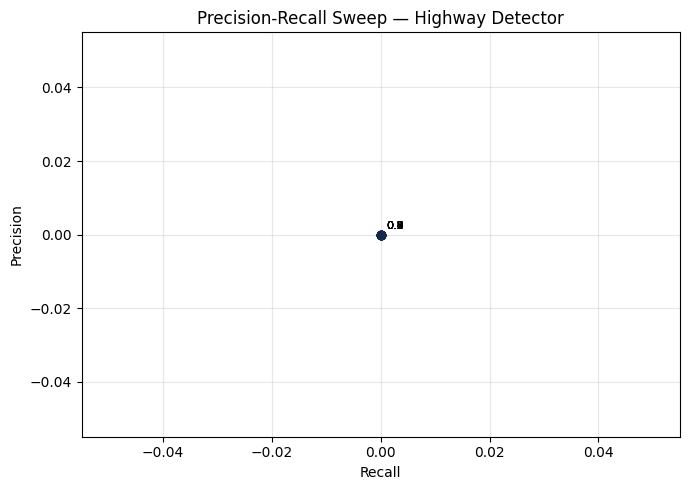

In [13]:
# ── Sweep confidence from 0.1 to 0.9 ─────────────────────────────
thresholds_sweep = np.arange(0.1, 1.0, 0.1)
img_bgr = cv2.imread(IMAGE_PATHS[0])
img_640 = cv2.resize(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB), (640,640))

precs, recs = [], []
for t in thresholds_sweep:
    res = model(img_640, conf=float(t), verbose=False)[0]
    n = len(res.boxes)
    gt_n = len(GROUND_TRUTH.get(IMAGE_PATHS[0],[]))
    tp = min(n, gt_n); fp = max(0, n-gt_n); fn = max(0, gt_n-n)
    p = tp/(tp+fp+1e-9); r = tp/(tp+fn+1e-9)
    precs.append(p); recs.append(r)

plt.figure(figsize=(7,5))
plt.plot(recs, precs, 'o-', color='#15294D', linewidth=2)
for t,r,p in zip(thresholds_sweep, recs, precs):
    plt.annotate(f"{t:.1f}", (r,p), fontsize=8, textcoords="offset points", xytext=(4,4))
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Sweep — Highway Detector')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
